In [1]:
import numpy as np   
from sklearn.linear_model import LinearRegression
import pandas as pd    
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function

In [2]:
cData = pd.read_csv("auto-mpg.csv")  
cData.shape

(398, 9)

In [3]:
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
cData = cData.drop(columns='car name',axis=1)

In [6]:
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [13]:
cData['origin'] = cData['origin'].replace({1:'America',2:'Europe',3:'Asia'})
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,America
1,15.0,8,350.0,165,3693,11.5,70,America
2,18.0,8,318.0,150,3436,11.0,70,America
3,16.0,8,304.0,150,3433,12.0,70,America
4,17.0,8,302.0,140,3449,10.5,70,America


In [25]:
cData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [17]:
cData.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [19]:
cData['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [21]:
cData[cData.horsepower.str.isdigit() == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
32,25.0,4,98.0,?,2046,19.0,71,America
126,21.0,6,200.0,?,2875,17.0,74,America
330,40.9,4,85.0,?,1835,17.3,80,Europe
336,23.6,4,140.0,?,2905,14.3,80,America
354,34.5,4,100.0,?,2320,15.8,81,Europe
374,23.0,4,151.0,?,3035,20.5,82,America


In [23]:
cData['horsepower'] = cData['horsepower'].astype(str)

In [27]:
#Step2 Convert horsepower to numeric (coerces '?' to NaN if still present)
cData['horsepower'] = cData['horsepower'].replace('?', np.nan)
cData['horsepower'] = pd.to_numeric(cData['horsepower'],errors='coerce')


In [29]:
# Step 3: Fill NaN values with median of horsepower
median_hp = cData['horsepower'].median()
cData['horsepower']=cData['horsepower'].fillna(median_hp)


In [31]:
cData.head(300)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,America
1,15.0,8,350.0,165.0,3693,11.5,70,America
2,18.0,8,318.0,150.0,3436,11.0,70,America
3,16.0,8,304.0,150.0,3433,12.0,70,America
4,17.0,8,302.0,140.0,3449,10.5,70,America
...,...,...,...,...,...,...,...,...
295,35.7,4,98.0,80.0,1915,14.4,79,America
296,27.4,4,121.0,80.0,2670,15.0,79,America
297,25.4,5,183.0,77.0,3530,20.1,79,Europe
298,23.0,8,350.0,125.0,3900,17.4,79,America


In [33]:
cData.horsepower.unique()

array([130. , 165. , 150. , 140. , 198. , 220. , 215. , 225. , 190. ,
       170. , 160. ,  95. ,  97. ,  85. ,  88. ,  46. ,  87. ,  90. ,
       113. , 200. , 210. , 193. ,  93.5, 100. , 105. , 175. , 153. ,
       180. , 110. ,  72. ,  86. ,  70. ,  76. ,  65. ,  69. ,  60. ,
        80. ,  54. , 208. , 155. , 112. ,  92. , 145. , 137. , 158. ,
       167. ,  94. , 107. , 230. ,  49. ,  75. ,  91. , 122. ,  67. ,
        83. ,  78. ,  52. ,  61. ,  93. , 148. , 129. ,  96. ,  71. ,
        98. , 115. ,  53. ,  81. ,  79. , 120. , 152. , 102. , 108. ,
        68. ,  58. , 149. ,  89. ,  63. ,  48. ,  66. , 139. , 103. ,
       125. , 133. , 138. , 135. , 142. ,  77. ,  62. , 132. ,  84. ,
        64. ,  74. , 116. ,  82. ])

In [35]:
df = pd.get_dummies(cData, columns=['origin'],dtype=int)

In [37]:
df.head(20)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
0,18.0,8,307.0,130.0,3504,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,1,0,0
5,15.0,8,429.0,198.0,4341,10.0,70,1,0,0
6,14.0,8,454.0,220.0,4354,9.0,70,1,0,0
7,14.0,8,440.0,215.0,4312,8.5,70,1,0,0
8,14.0,8,455.0,225.0,4425,10.0,70,1,0,0
9,15.0,8,390.0,190.0,3850,8.5,70,1,0,0


In [39]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,0.625628,0.198492,0.175879
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.484569,0.399367,0.381197
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000,0.000000,0.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,0.000000,0.000000,0.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,0.000000,0.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,1.000000,0.000000,0.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,1.000000,1.000000,1.000000


In [41]:
df.groupby(['model year']).describe()

mpg                                                          \
           count       mean       std   min     25%    50%     75%   max   
model year                                                                 
70          29.0  17.689655  5.339231   9.0  14.000  16.00  22.000  27.0   
71          28.0  21.250000  6.591942  12.0  15.500  19.00  27.000  35.0   
72          28.0  18.714286  5.435529  11.0  13.750  18.50  23.000  28.0   
73          40.0  17.100000  4.700245  11.0  13.000  16.00  20.000  29.0   
74          27.0  22.703704  6.420010  13.0  16.000  24.00  27.000  32.0   
75          30.0  20.266667  4.940566  13.0  16.000  19.50  23.000  33.0   
76          34.0  21.573529  5.889297  13.0  16.750  21.00  26.375  33.0   
77          28.0  23.375000  6.675862  15.0  17.375  21.75  30.000  36.0   
78          36.0  24.061111  6.898044  16.2  19.350  20.70  28.000  43.1   
79          29.0  25.093103  6.794217  15.5  19.200  23.90  31.800  37.3   
80          29.0  33.696552  7.037983  19.1  29.800  32.70  38.100  46.6   
81          29.0  30.334483  5.591465  17.6  26.600  31.60  34.400  39.1   
82          31.0  31.709677  5.392548  22.0  27.000  32.00  36.000  44.0   

           cylinders            ... origin_Asia      origin_Europe            \
               count      mean  ...         75%  max         count      mean   
model year                      ...                                            
70              29.0  6.758621  ...         0.0  1.0          29.0  0.172414   
71              28.0  5.571429  ...         0.0  1.0          28.0  0.142857   
72              28.0  5.821429  ...         0.0  1.0          28.0  0.178571   
73              40.0  6.375000  ...         0.0  1.0          40.0  0.175000   
74              27.0  5.259259  ...         0.0  1.0          27.0  0.222222   
75              30.0  5.600000  ...         0.0  1.0          30.0  0.200000   
76              34.0  5.647059  ...         0.0  1.0          34.0  0.235294   
77              28.0  5.464286  ...         0.0  1.0          28.0  0.142857   
78              36.0  5.361111  ...         0.0  1.0          36.0  0.166667   
79              29.0  5.827586  ...         0.0  1.0          29.0  0.137931   
80              29.0  4.137931  ...         1.0  1.0          29.0  0.310345   
81              29.0  4.620690  ...         1.0  1.0          29.0  0.137931   
82              31.0  4.193548  ...         1.0  1.0          31.0  0.064516   

                                               
                 std  min  25%  50%  75%  max  
model year                                     
70          0.384426  0.0  0.0  0.0  0.0  1.0  
71          0.356348  0.0  0.0  0.0  0.0  1.0  
72          0.390021  0.0  0.0  0.0  0.0  1.0  
73          0.384808  0.0  0.0  0.0  0.0  1.0  
74          0.423659  0.0  0.0  0.0  0.0  1.0  
75          0.406838  0.0  0.0  0.0  0.0  1.0  
76          0.430562  0.0  0.0  0.0  0.0  1.0  
77          0.356348  0.0  0.0  0.0  0.0  1.0  
78          0.377964  0.0  0.0  0.0  0.0  1.0  
79          0.350931  0.0  0.0  0.0  0.0  1.0  
80          0.470824  0.0  0.0  0.0  1.0  1.0  
81          0.350931  0.0  0.0  0.0  0.0  1.0  
82          0.249731  0.0  0.0  0.0  0.0  1.0  

[13 rows x 72 columns]

In [45]:
df.groupby(['model year','cylinders']).median()

mpg  displacement  horsepower  weight  acceleration  \
model year cylinders                                                          
70         4          25.00         107.0        90.0  2372.0         15.00   
           6          21.00         199.0        92.5  2711.0         15.50   
           8          14.50         355.0       191.5  3805.5         10.25   
71         4          27.00          97.0        76.0  2074.0         18.00   
           6          18.00         250.0       100.0  3285.0         15.25   
           8          14.00         383.0       170.0  4464.0         12.00   
72         3          19.00          70.0        97.0  2330.0         13.50   
           4          23.00         116.5        86.5  2283.0         16.75   
           8          13.00         350.0       153.0  4274.0         13.00   
73         3          18.00          70.0        90.0  2124.0         13.50   
           4          22.00         114.0        88.0  2310.0         16.50   
           6          18.00         228.5       100.0  2924.5         16.00   
           8          13.00         350.5       162.5  4257.5         12.50   
74         4          26.00          90.0        75.0  2125.0         16.00   
           6          18.00         232.0       100.0  3336.0         17.00   
           8          14.00         304.0       150.0  4457.0         14.50   
75         4          24.00         119.5        85.5  2615.5         16.25   
           6          18.00         232.0        98.5  3348.0         17.75   
           8          15.50         334.0       146.5  4469.0         13.50   
76         4          27.00          98.0        75.0  2202.0         16.40   
           6          19.50         228.5       100.0  3293.0         17.15   
           8          14.50         318.0       150.0  4055.0         13.00   
77         3          21.50          80.0       110.0  2720.0         13.50   
           4          30.00          98.0        78.0  2115.0         15.95   
           6          19.00         231.0       100.0  3520.0         16.90   
           8          15.75         334.0       147.0  4192.5         13.10   
78         4          29.50         105.0        75.0  2230.0         15.70   
           5          20.30         131.0       103.0  2830.0         15.90   
           6          19.30         225.0       105.0  3395.0         16.25   
           8          19.30         303.5       139.5  3497.5         13.20   
79         4          32.70         105.0        71.0  2175.0         14.95   
           5          25.40         183.0        77.0  3530.0         20.10   
           6          21.05         212.5       112.5  3117.5         16.00   
           8          17.90         334.0       132.5  3870.0         14.95   
80         3          23.70          70.0       100.0  2420.0         12.50   
           4          33.80          98.0        75.0  2265.0         16.50   
           5          36.40         121.0        67.0  2950.0         19.90   
           6          25.90         196.5       111.0  3145.5         15.05   
81         4          33.00         105.0        74.0  2215.0         16.20   
           6          23.50         173.0       110.0  3060.0         15.80   
           8          26.60         350.0       105.0  3725.0         19.00   
82         4          32.00         112.0        84.0  2382.5         16.30   
           6          25.00         232.0       110.0  2945.0         16.40   

                      origin_America  origin_Asia  origin_Europe  
model year cylinders                                              
70         4                     0.0          0.0            1.0  
           6                     1.0          0.0            0.0  
           8                     1.0          0.0            0.0  
71         4                     0.0          0.0            0.0  
           6                     1.0          0.0            0.0  

In [47]:
df.cov()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
mpg,61.089611,-10.308911,-655.402318,-231.067162,-5505.211745,9.058930,16.741163,-2.151961,1.380224,0.771738
cylinders,-10.308911,2.893415,168.623214,54.697663,1290.695575,-2.370842,-2.193499,0.498139,-0.269338,-0.228801
displacement,-655.402318,168.623214,10872.199152,3570.094379,82368.423240,-156.332976,-142.717137,32.912987,-18.052001,-14.860986
horsepower,-231.067162,54.697663,3570.094379,1460.969052,27915.978893,-72.370753,-58.474096,8.990678,-4.869062,-4.121616
weight,-5505.211745,1290.695575,82368.423240,27915.978893,717140.990526,-974.899011,-959.946344,245.554833,-149.084497,-96.470337
acceleration,9.058930,-2.370842,-156.332976,-72.370753,-974.899011,7.604848,2.938105,-0.335150,0.120204,0.214946
model year,16.741163,-2.193499,-142.717137,-58.474096,-959.946344,2.938105,13.672443,-0.250636,0.285154,-0.034518
origin_America,-2.151961,0.498139,32.912987,8.990678,245.554833,-0.335150,-0.250636,0.234808,-0.124495,-0.110312
origin_Asia,1.380224,-0.269338,-18.052001,-4.869062,-149.084497,0.120204,0.285154,-0.124495,0.159494,-0.034999
origin_Europe,0.771738,-0.228801,-14.860986,-4.121616,-96.470337,0.214946,-0.034518,-0.110312,-0.034999,0.145311


In [49]:
df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_America,origin_Asia,origin_Europe
mpg,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267,-0.568192,0.442174,0.259022
cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746,0.604351,-0.396479,-0.352861
displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164,0.651407,-0.433505,-0.373886
horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733,0.485418,-0.318972,-0.282877
weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564,0.598398,-0.440817,-0.298843
acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137,-0.250806,0.109144,0.204473
model year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000,-0.139883,0.193101,-0.024489
origin_America,-0.568192,0.604351,0.651407,0.485418,0.598398,-0.250806,-0.139883,1.000000,-0.643317,-0.597198
origin_Asia,0.442174,-0.396479,-0.433505,-0.318972,-0.440817,0.109144,0.193101,-0.643317,1.000000,-0.229895
origin_Europe,0.259022,-0.352861,-0.373886,-0.282877,-0.298843,0.204473,-0.024489,-0.597198,-0.229895,1.000000


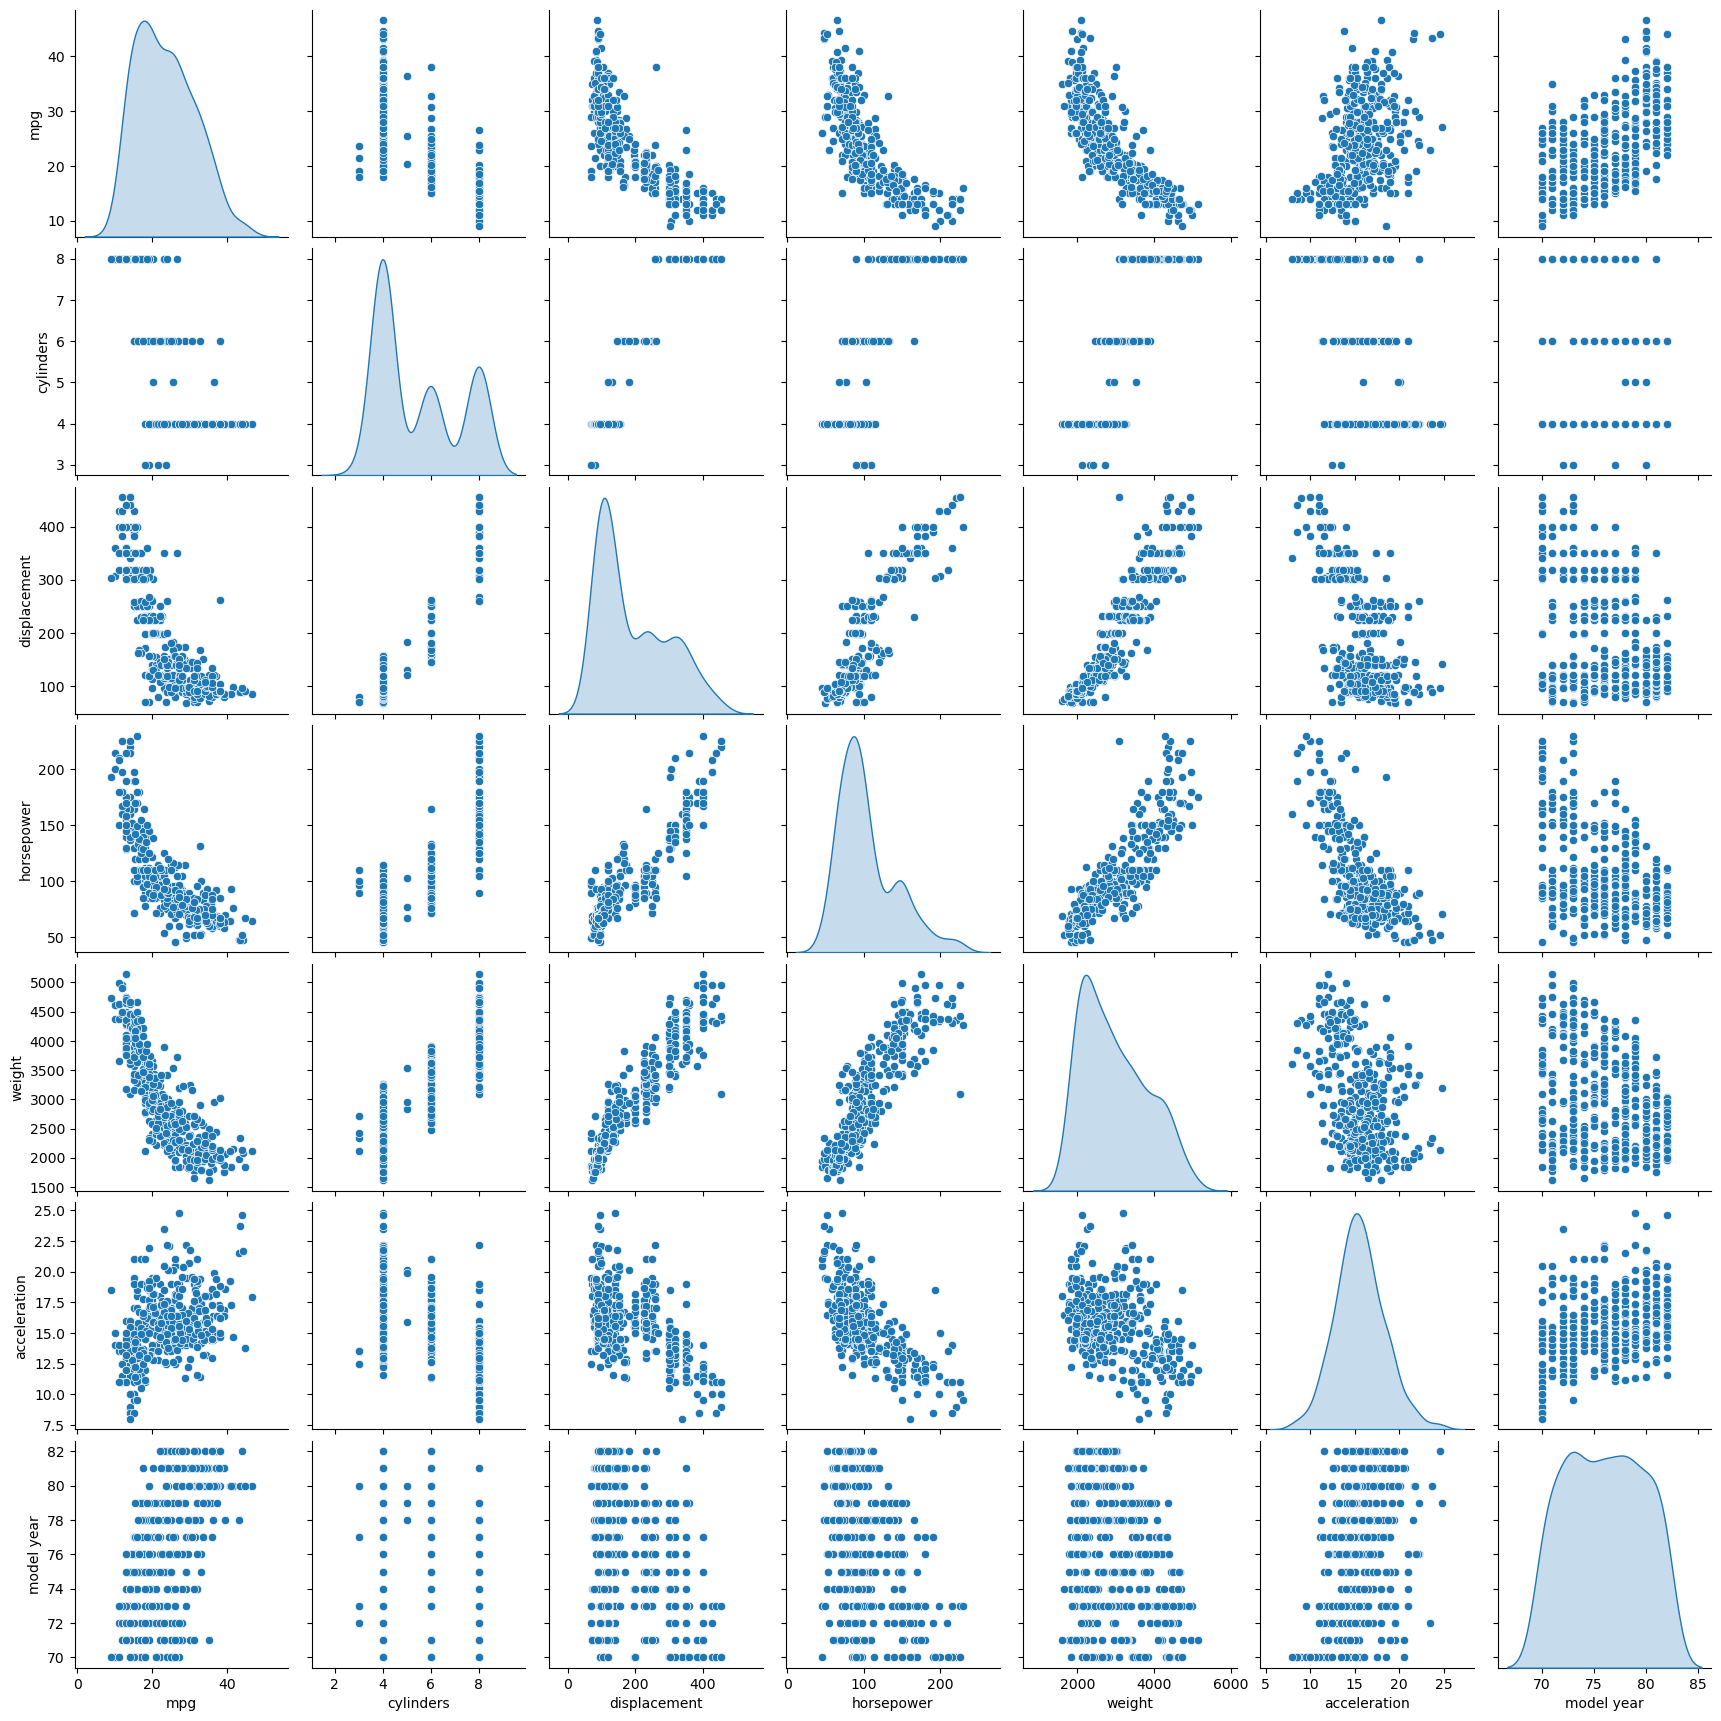

In [51]:
sns.pairplot(df.iloc[:,:7],diag_kind='kde');

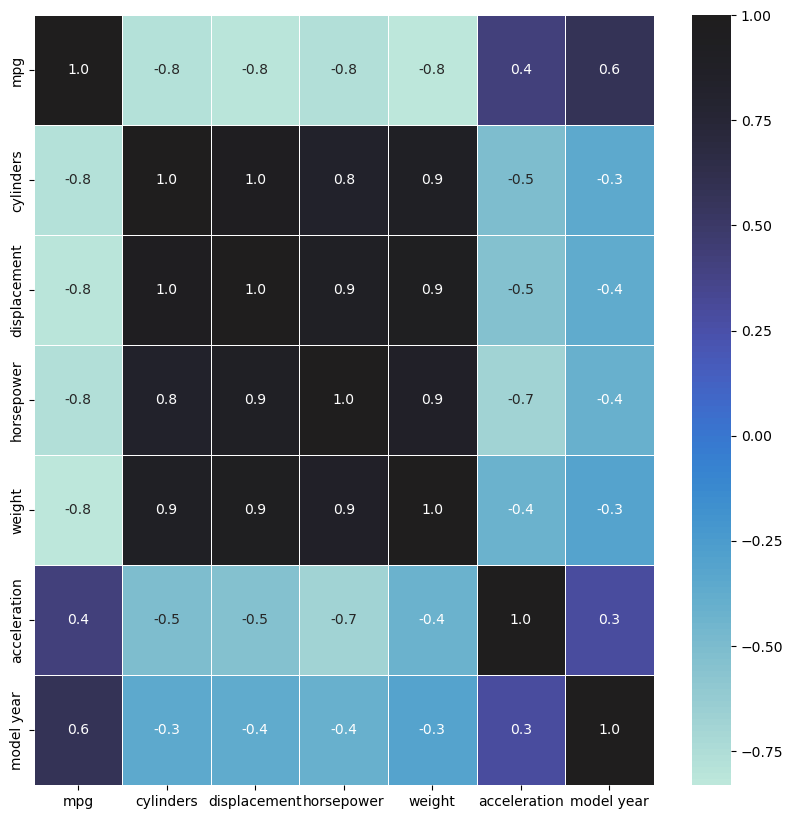

In [53]:
# Heatmap
df_attr = df.iloc[:,:7]
fig,ax = plt.subplots(figsize=(10,10))
sns.heatmap(df_attr.corr(),ax=ax, annot=True,linewidths=0.5, fmt= '.1f', center = 1)
plt.show()

In [55]:
df.skew()

mpg               0.457066
cylinders         0.526922
displacement      0.719645
horsepower        1.106224
weight            0.531063
acceleration      0.278777
model year        0.011535
origin_America   -0.521133
origin_Asia       1.517553
origin_Europe     1.709131
dtype: float64

## Univariate Analysis

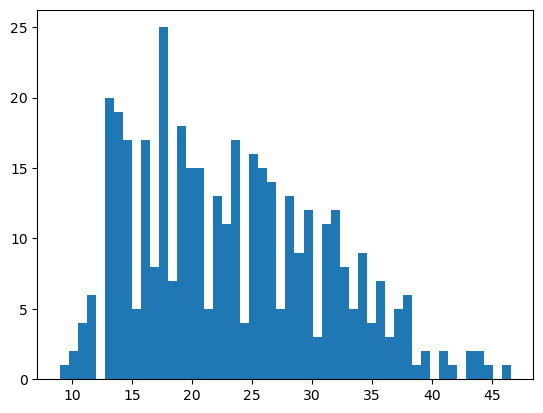

In [57]:
plt.hist(df['mpg'],bins=50);

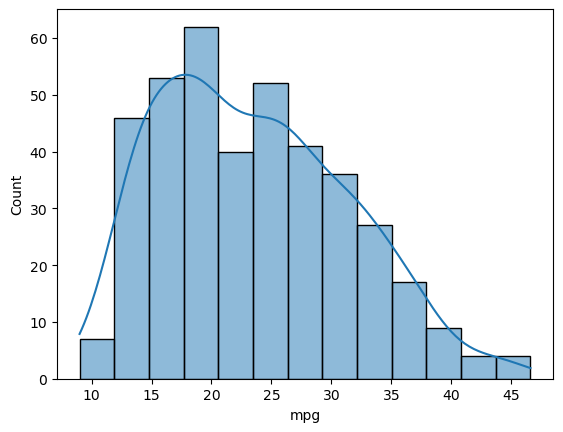

In [59]:
sns.histplot(df['mpg'],kde=True);

In [61]:
df_attr.groupby('model year').describe().transpose()

model year                   70           71           72           73  \
mpg          count    29.000000    28.000000    28.000000    40.000000   
             mean     17.689655    21.250000    18.714286    17.100000   
             std       5.339231     6.591942     5.435529     4.700245   
             min       9.000000    12.000000    11.000000    11.000000   
             25%      14.000000    15.500000    13.750000    13.000000   
             50%      16.000000    19.000000    18.500000    16.000000   
             75%      22.000000    27.000000    23.000000    20.000000   
             max      27.000000    35.000000    28.000000    29.000000   
cylinders    count    29.000000    28.000000    28.000000    40.000000   
             mean      6.758621     5.571429     5.821429     6.375000   
             std       1.724926     1.665079     2.073708     1.807215   
             min       4.000000     4.000000     3.000000     3.000000   
             25%       6.000000     4.000000     4.000000     4.000000   
             50%       8.000000     6.000000     4.000000     7.000000   
             75%       8.000000     6.500000     8.000000     8.000000   
             max       8.000000     8.000000     8.000000     8.000000   
displacement count    29.000000    28.000000    28.000000    40.000000   
             mean    281.413793   209.750000   218.375000   256.875000   
             std     124.421380   115.102410   123.781964   121.722085   
             min      97.000000    71.000000    70.000000    68.000000   
             25%     198.000000    97.750000   109.250000   121.750000   
             50%     307.000000   228.500000   131.000000   276.000000   
             75%     383.000000   273.000000   326.000000   350.250000   
             max     455.000000   400.000000   429.000000   455.000000   
horsepower   count    29.000000    28.000000    28.000000    40.000000   
             mean    147.827586   106.553571   120.178571   130.475000   
             std      53.734844    37.931551    41.121368    46.412304   
             min      46.000000    60.000000    54.000000    46.000000   
             25%      95.000000    83.500000    86.750000    93.250000   
             50%     150.000000    94.250000   104.500000   129.500000   
             75%     198.000000   120.000000   150.750000   160.250000   
             max     225.000000   180.000000   208.000000   230.000000   
weight       count    29.000000    28.000000    28.000000    40.000000   
             mean   3372.793103  2995.428571  3237.714286  3419.025000   
             std     852.868663  1061.830859   974.520960   974.809133   
             min    1835.000000  1613.000000  2100.000000  1867.000000   
             25%    2648.000000  2110.750000  2285.500000  2554.500000   
             50%    3449.000000  2798.000000  2956.000000  3338.500000   
             75%    4312.000000  3603.250000  4169.750000  4247.250000   
             max    4732.000000  5140.000000  4633.000000  4997.000000   
acceleration count    29.000000    28.000000    28.000000    40.000000   
             mean     12.948276    15.142857    15.125000    14.312500   
             std       3.330982     2.666171     2.850032     2.754222   
             min       8.000000    11.500000    11.000000     9.500000   
             25%      10.000000    13.375000    13.375000    12.500000   
             50%      12.500000    14.500000    14.500000    14.000000   
             75%      15.000000    16.125000    16.625000    16.000000   
             max      20.500000    20.500000    23.500000    21.000000   

model year                   74           75           76           77  \
mpg          count    27.000000    30.000000    34.000000    28.000000   
             mean     22.703704    20.266667    21.573529    23.375000   
             std       6.420010     4.940566     5.889297     6.675862   
             min      13.000000    13.000000    13.000000    15.000000   
   

In [63]:
df_attr.groupby(['model year','cylinders']).mean()

mpg  displacement  horsepower       weight  \
model year cylinders                                                     
70         4          25.285714    107.000000   87.714286  2292.571429   
           6          20.500000    199.000000   91.750000  2710.500000   
           8          14.111111    367.555556  183.666667  3940.055556   
71         4          27.461538    101.846154   78.807692  2056.384615   
           6          18.000000    243.375000   98.875000  3171.875000   
           8          13.428571    371.714286  166.857143  4537.714286   
72         3          19.000000     70.000000   97.000000  2330.000000   
           4          23.428571    111.535714   85.142857  2382.642857   
           8          13.615385    344.846154  159.692308  4228.384615   
73         3          18.000000     70.000000   90.000000  2124.000000   
           4          22.727273    109.272727   82.909091  2338.090909   
           6          19.000000    212.250000  102.125000  2917.125000   
           8          13.200000    365.250000  170.000000  4279.050000   
74         4          27.800000     96.533333   74.000000  2151.466667   
           6          17.857143    230.428571  100.500000  3320.000000   
           8          14.200000    315.200000  146.000000  4438.400000   
75         4          25.250000    114.833333   84.916667  2489.250000   
           6          17.583333    233.750000   96.750000  3398.333333   
           8          15.666667    330.500000  142.000000  4108.833333   
76         4          26.766667    106.333333   75.600000  2306.600000   
           6          20.000000    221.400000   98.700000  3349.600000   
           8          14.666667    324.000000  146.333333  4064.666667   
77         3          21.500000     80.000000  110.000000  2720.000000   
           4          29.107143    106.500000   78.785714  2205.071429   
           6          19.500000    220.400000  102.000000  3383.000000   
           8          16.000000    335.750000  152.375000  4177.500000   
78         4          29.576471    112.117647   79.705882  2296.764706   
           5          20.300000    131.000000  103.000000  2830.000000   
           6          19.066667    213.250000  109.833333  3314.166667   
           8          19.050000    300.833333  135.500000  3563.333333   
79         4          31.525000    113.583333   75.750000  2357.583333   
           5          25.400000    183.000000   77.000000  3530.000000   
           6          22.950000    205.666667  105.000000  3025.833333   
           8          18.630000    321.400000  131.900000  3862.900000   
80         3          23.700000     70.000000  100.000000  2420.000000   
           4          34.612000    111.000000   75.600000  2360.080000   
           5          36.400000    121.000000   67.000000  2950.000000   
           6          25.900000    196.500000  111.000000  3145.500000   
81         4          32.814286    108.857143   73.928571  2275.476190   
           6          23.428571    184.000000  100.714286  3093.571429   
           8          26.600000    350.000000  105.000000  3725.000000   
82         4          32.071429    118.571429   79.660714  2402.321429   
           6          28.333333    225.000000  102.333333  2931.666667   

                      acceleration  
model year cylinders                
70         4             16.000000  
           6             15.500000  
           8             11.194444  
71         4             16.961538  
           6             14.750000  
           8             12.214286  
72         3             13.500000  
           4             17.214286  
           8             13.000000  
73         3             13.500000  
           4             17.136364  
           6             15.687500  
           8             12.250000  
74         4             16.400000  
           6             16.857143  
           8             14.700000  
75         4             15.833

In [65]:
df_attr.groupby('model year').median()

,mpg,cylinders,displacement,horsepower,weight,acceleration
model year,,,,,,
70,16.00,8.0,307.0,150.00,3449.0,12.50
71,19.00,6.0,228.5,94.25,2798.0,14.50
72,18.50,4.0,131.0,104.50,2956.0,14.50
73,16.00,7.0,276.0,129.50,3338.5,14.00
74,24.00,4.0,122.0,93.00,2489.0,16.00
75,19.50,6.0,228.0,97.00,3098.5,16.00
76,21.00,6.0,184.0,93.50,3171.5,15.50
77,21.75,4.0,143.0,97.50,2747.5,15.65
78,20.70,5.5,159.5,97.00,2910.0,15.75


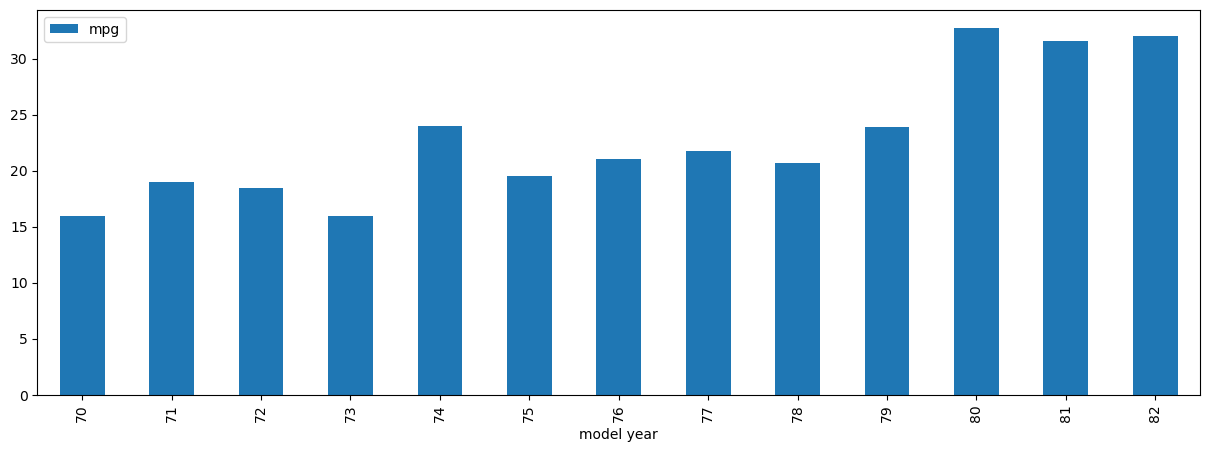

In [81]:
df_attr.groupby('model year').median().reset_index().plot(x='model year',y='mpg',kind='bar',figsize=(15,5))
plt.show()

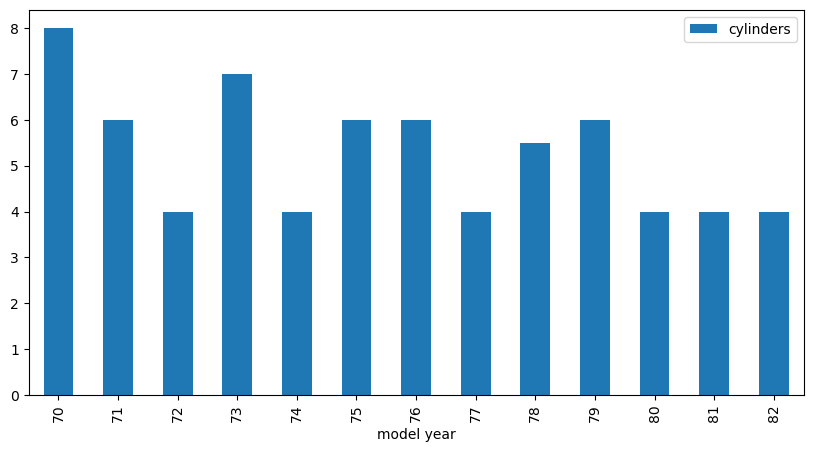

In [69]:
df_attr.groupby('model year').median().reset_index().plot(x='model year',y='cylinders',kind='bar',figsize=(10,5))
plt.show()

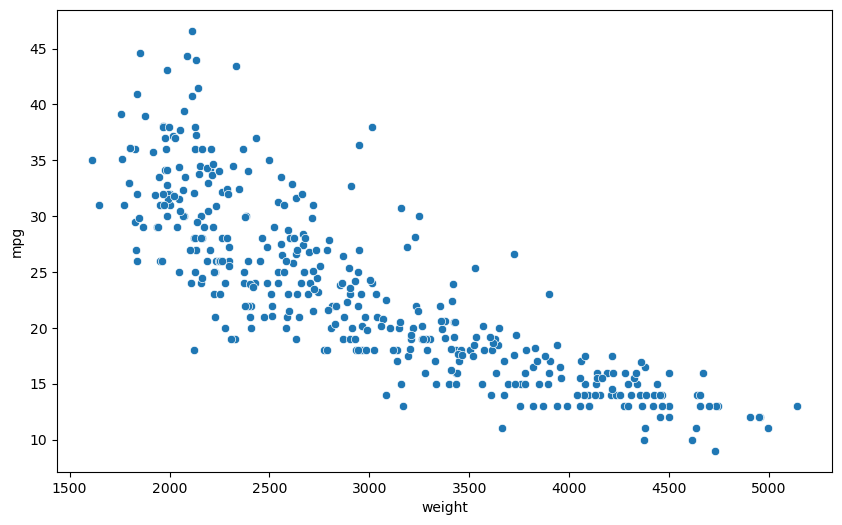

In [71]:
plt.figure(figsize=(10,6))
ax = sns.scatterplot(data=df, x='weight',y='mpg');

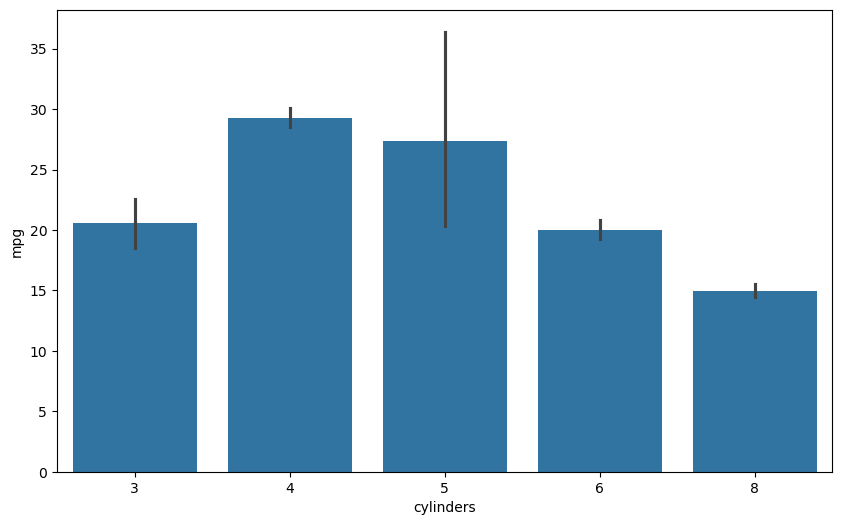

In [73]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x='cylinders',y='mpg');

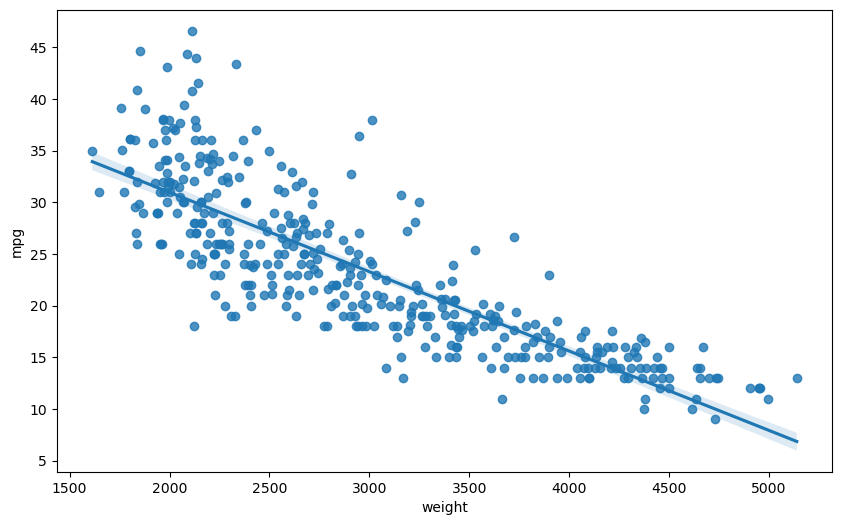

In [75]:
plt.figure(figsize=(10,6))
ax = sns.regplot(data=df, x='weight',y='mpg');

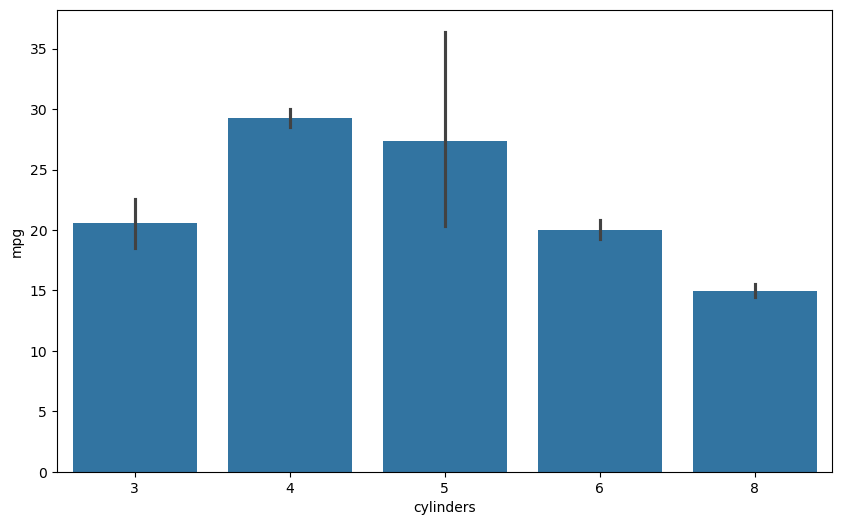

In [87]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x='cylinders',y='mpg');

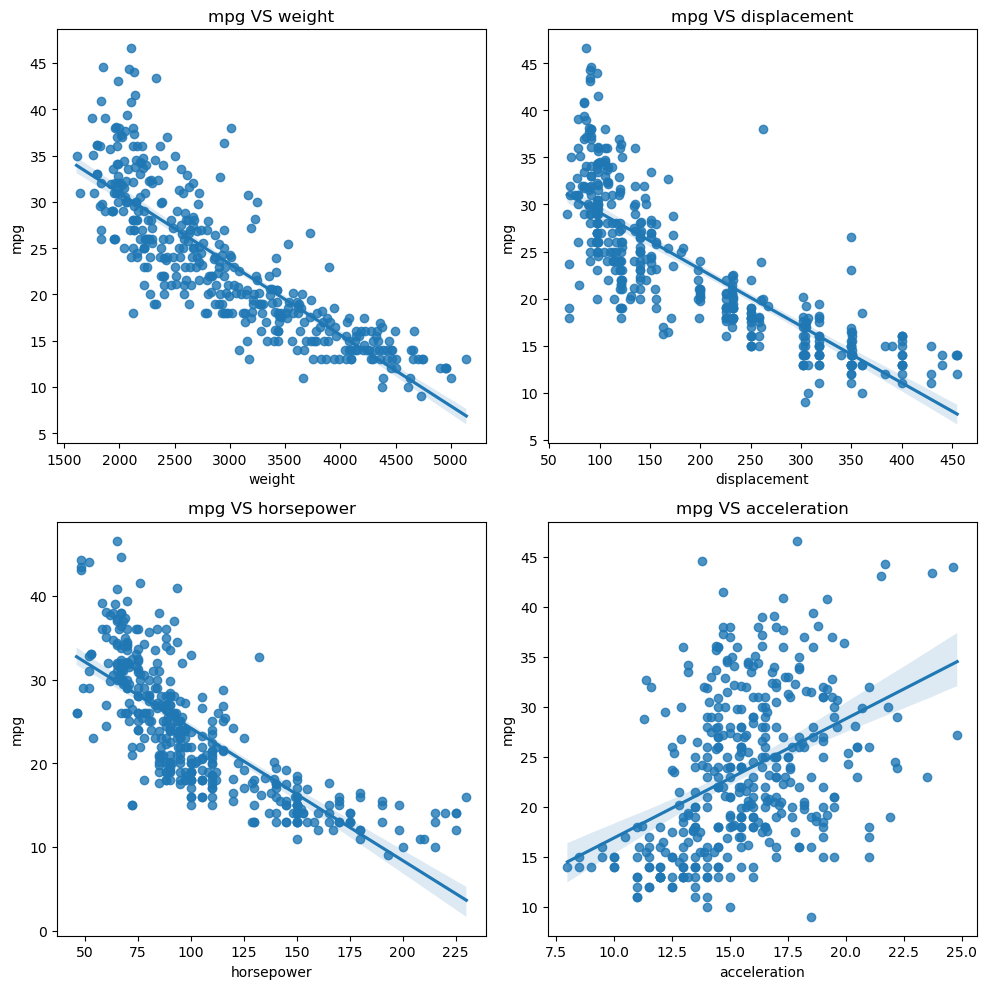

In [89]:
fig,axs = plt.subplots(2,2,figsize=(10,10))

#mpg	cylinders	displacement	horsepower	weight	acceleration

sns.regplot(data=df, x='weight',y='mpg', ax=axs[0,0]);
axs[0, 0].set_title("mpg VS weight")
axs[0, 0].set_xlabel("weight")
axs[0, 0].set_ylabel("mpg")

sns.regplot(data=df, x='displacement',y='mpg', ax=axs[0, 1]);
axs[0, 1].set_title("mpg VS displacement")
axs[0, 1].set_xlabel("displacement")
axs[0, 1].set_ylabel("mpg")

sns.regplot(data=df, x='horsepower',y='mpg', ax=axs[1, 0]);
axs[1, 0].set_title("mpg VS horsepower")
axs[1, 0].set_xlabel("horsepower")
axs[1, 0].set_ylabel("mpg")

sns.regplot(data=df, x='acceleration',y='mpg', ax=axs[1, 1]);
axs[1, 1].set_title("mpg VS acceleration")
axs[1, 1].set_xlabel("acceleration")
axs[1, 0].set_ylabel("mpg")


plt.tight_layout()



## Split Data

In [91]:
# lets build our linear model
# independant variables
X = df.drop(['mpg'], axis=1)
# the dependent variable
y = df[['mpg']]

In [93]:
# Split X and y into training and test set in 70:30 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

## Fit Linear Model

In [96]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [98]:
regression_model.coef_

array([[-0.39480797,  0.02894551, -0.02175221, -0.00735203,  0.06191937,
         0.83693389, -1.79884935,  0.59641569,  1.20243366]])

In [100]:
X_train.columns

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin_America', 'origin_Asia', 'origin_Europe'],
      dtype='object')

In [104]:
for idx, cols in enumerate(X_train.columns):
    print(f"The coefficient for {cols} is {regression_model.coef_[0][idx]}")

The coefficient for cylinders is -0.3948079661648261
The coefficient for displacement is 0.028945510765487487
The coefficient for horsepower is -0.021752207723547134
The coefficient for weight is -0.007352032065147359
The coefficient for acceleration is 0.061919366007619714
The coefficient for model year is 0.8369338917645018
The coefficient for origin_America is -1.7988493458374293
The coefficient for origin_Asia is 0.5964156907563446
The coefficient for origin_Europe is 1.2024336550810846


In [108]:
intercept = regression_model.intercept_[0]
print(f"The intercept for our model is {intercept}")

The intercept for our model is -19.485884771453346


In [140]:
y_pred_reg = regression_model.predict(X_test)

In [110]:
regression_model.score(X_train, y_train)

0.8141025501610559

In [112]:
regression_model.score(X_test, y_test)

0.8433135132808829

## Adding interaction terms 


In [116]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(X_train2, y_train)

y_pred = poly_clf.predict(X_test2)

#print(y_pred)

#In sample (training) R^2 will always improve with the number of variables!
print(poly_clf.score(X_train2, y_train))

0.8995492104709468


In [118]:
#Out off sample (testing) R^2 is our measure of sucess and does improve
print(poly_clf.score(X_test2, y_test))

0.8613490753533375


In [120]:
# but this improves as the cost of 29 extra variables!
print(X_train.shape)
print(X_train2.shape)

(278, 9)
(278, 46)


In [134]:
from sklearn.metrics import mean_squared_error, r2_score

In [136]:
# The coefficients
print("Coefficients: \n", poly_clf.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Coefficients: 
 [[-8.87645111e+07  8.26216891e+00 -3.49038383e-01  6.41059517e-01
  -1.93630043e-02 -3.25747281e+00  8.53079342e-01  3.42594933e+01
  -2.42507650e+01 -1.00087283e+01 -2.31203266e-02  4.24596387e-02
   1.92728768e-03  3.07374905e-01 -2.87764975e-01  2.74216028e+00
   4.50322383e+00  1.01678480e+00  5.23926949e-05  2.92422652e-05
  -1.92685317e-03  6.70335028e-03 -7.75896537e-02 -1.33644116e-01
  -1.37804614e-01 -7.12022500e-05 -1.34185380e-03 -1.15627138e-02
   1.42105379e-01  2.68869373e-01  2.30084766e-01 -2.07665853e-04
   1.80219284e-04 -6.34344243e-03 -8.55266567e-03 -4.46689639e-03
   5.12713562e-02 -1.69905845e+00 -9.76984116e-01 -5.81430246e-01
  -2.39664104e-02  5.08881227e-01  3.68164525e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
Mean squared error: 8.11
Coefficient of determination: 0.86


In [144]:
X_test.shape, y_test.shape, y_pred_reg.shape

((120, 9), (120, 1), (120, 1))

In [146]:
# # Plot outputs
# plt.scatter(X_test, y_test, color="black")
# plt.plot(X_test, y_pred_reg, color="blue", linewidth=3)

# plt.xticks(())
# plt.yticks(())

# plt.show()

## Lets scale the Data, convert to np.array

In [149]:
# lets build our linear model
# independant variables
X = df.drop(['mpg'], axis=1)
# the dependent variable
y = df[['mpg']]

In [165]:
from sklearn import preprocessing

X_scaled = preprocessing.scale(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)  # ideally the training and test should be 

y_scaled = preprocessing.scale(y)
y_scaled = pd.DataFrame(y_scaled, columns=y.columns)  # ideally the training and test should be 

In [167]:
y_scaled.head()

,mpg
0,-0.706439
1,-1.090751
2,-0.706439
3,-0.962647
4,-0.834543


In [169]:
# Split X and y into training and test set in 70:30 ratio

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y_scaled, test_size=0.30, random_state=1)

In [171]:
regression_model_scaled = LinearRegression()
regression_model_scaled.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [183]:
y_pred_scaled = regression_model_scaled.predict(X_test_scaled)

In [175]:
regression_model_scaled.coef_

array([[-0.08592264,  0.38615018, -0.10637515, -0.79657374,  0.02184681,
         0.39594105, -0.09399897,  0.04491789,  0.0724306 ]])

In [179]:
regression_model_scaled.intercept_[0]

0.015510225561902385

In [181]:
for idx, cols in enumerate(X_train_scaled.columns):
    print(f"The coefficient for {cols} is {regression_model.coef_[0][idx]}")

The coefficient for cylinders is -0.3948079661648261
The coefficient for displacement is 0.028945510765487487
The coefficient for horsepower is -0.021752207723547134
The coefficient for weight is -0.007352032065147359
The coefficient for acceleration is 0.061919366007619714
The coefficient for model year is 0.8369338917645018
The coefficient for origin_America is -1.7988493458374293
The coefficient for origin_Asia is 0.5964156907563446
The coefficient for origin_Europe is 1.2024336550810846


In [185]:
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test_scaled, y_pred_scaled))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test_scaled, y_pred_scaled))

Mean squared error: 0.15
Coefficient of determination: 0.84


In [187]:
X_test_scaled.shape, y_test_scaled.shape, y_pred_scaled.shape

((120, 9), (120, 1), (120, 1))

In [217]:
X_test_scaled.iloc[:,3]

174    0.016051
359    0.306908
250    0.903991
274   -0.166030
283    0.348290
         ...   
382   -0.857702
39     1.765921
171   -0.317370
271   -0.266530
247   -1.064612
Name: weight, Length: 120, dtype: float64

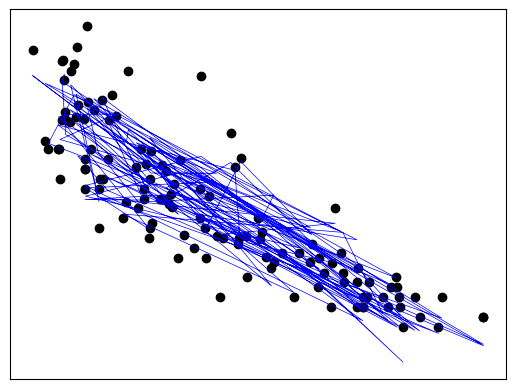

In [229]:
# Plot outputs
plt.scatter(X_test_scaled.iloc[:,3], y_test_scaled, color="black")
plt.plot(X_test_scaled.iloc[:,3], y_pred_scaled, color="blue", linewidth=0.5)

plt.xticks(())
plt.yticks(())

plt.show()